# Laboratorio 8: DuckDB

## Ejercicio 3. Consultas directas sobre archivos Parquet

**Equipo:** Abby Donis (22440), Hansel Lopez (19026), Fabian Prado (23427)

CC3084 Data Science, Semestre II 2026 | 2026-10-06

**Pregunta:** que contienen los archivos Parquet de 2026 y que problemas de calidad tienen, si se consultan directo con DuckDB sin importarlos antes a ninguna tabla?

**Datos.** Los 16 archivos de enero a agosto de 2026 que descarga el cuaderno 01 en `data/raw/<tipo>/2026/`. Si no estan, correr antes `python scripts/download_data.py` desde la raiz del laboratorio.

**Como se consulta (3.7).** Todas las consultas leen los archivos con `read_parquet`, `parquet_schema`, `parquet_file_metadata` o `glob`, sobre una conexion de DuckDB en memoria y sin vistas: no hay ninguna tabla ni copia intermedia. Cada consulta vive en su propio archivo de `sql/` (prefijo `02_`); el cuaderno imprime el SQL antes de cada resultado y `docs/consultas.md` documenta objetivo, fuente, resultado y decision de cada una (3.8).

## Mapa del notebook

1. Imports y configuracion
2. Obtencion de datos: correr, medir y explicar consultas de `sql/`
3. Preparacion de datos: tablas de esquema, perfil y calidad
4. Variables: no aplica
5. Metricas: porcentaje de registros afectados por cada problema
6. Graficas: prevalencia de los problemas y costo de las consultas
7. Ejecucion: archivos (3.1), registros (3.2), columnas (3.3), tipos (3.4), muestra (3.5), calidad (3.6), costo de leer directo (3.9) y bitacora de consultas (3.8)
8. Conclusiones y decisiones para el analisis exploratorio

## 1. Imports y configuracion

Igual que en el cuaderno 01, las rutas salen de `scripts/consultas.py`. `SEED` es la semilla de las muestras: va escrita dentro de los archivos `02_muestra_*.sql` porque DuckDB la recibe en el propio SQL. `BITACORA` guarda una fila por cada consulta que corre el cuaderno, para el resumen del paso 7.13.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

RAIZ_LAB = Path.cwd() if (Path.cwd() / "scripts").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ_LAB / "scripts"))
import consultas

SEED = 42  # semilla de 02_muestra_yellow.sql y 02_muestra_green.sql
RAIZ = consultas.RAIZ
DIR_FIGURAS = RAIZ / "data" / "processed" / "figuras"
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

TIPOS = ("yellow", "green")
COLOR_TAXI = {"yellow": "#e0a100", "green": "#2e8b57"}
REPETICIONES = 3  # corridas por consulta al medir tiempos; se reporta la menor
BITACORA = []

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": True,
})
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

## 2. Obtencion de datos

Tres formas de usar un archivo de `sql/`. `correr` imprime la consulta, la ejecuta y la anota en la bitacora. `medir` la corre varias veces y se queda con el menor tiempo, porque la primera corrida paga la lectura en frio del disco y las siguientes miden el trabajo de DuckDB. `plan` pide a DuckDB el plan de ejecucion sin correr la consulta, para ver que columnas y filtros llegan a la lectura del archivo.

In [2]:
def correr(con, nombre, mostrar=True):
    """Imprime una consulta de sql/, la ejecuta sobre los Parquet y la anota en la bitacora."""
    if mostrar:
        print(consultas.leer_sql(nombre))
    resultado, segundos = consultas.correr_medido(con, nombre)
    BITACORA.append({"consulta": nombre, "filas_resultado": len(resultado), "segundos": round(segundos, 3)})
    return resultado


def medir(con, nombre, repeticiones=REPETICIONES):
    """Menor tiempo, en segundos, de varias corridas de la misma consulta."""
    tiempos = [consultas.correr_medido(con, nombre)[1] for _ in range(repeticiones)]
    BITACORA.append({"consulta": nombre, "filas_resultado": 1, "segundos": round(min(tiempos), 3)})
    return min(tiempos)


def plan(con, nombre):
    """Plan fisico que DuckDB arma para una consulta de sql/, sin ejecutarla."""
    sql = "\n".join(l for l in consultas.leer_sql(nombre).splitlines() if not l.strip().startswith("--"))
    return con.sql("explain " + sql).df()["explain_value"].iloc[0]

## 3. Preparacion de datos

No se modifica ningun dato: este ejercicio es de exploracion y las decisiones de limpieza se aplican en el cuaderno 03. Estas funciones solo reorganizan resultados para leerlos mejor: el esquema de los dos tipos en una sola tabla, el perfil reducido a las columnas que hablan de calidad, las reglas de calidad como filas con su porcentaje, y el plan de DuckDB sin los caracteres de dibujo.

In [3]:
def tipo_logico_corto(texto):
    """Nombre corto del tipo logico que guarda el Parquet."""
    if not isinstance(texto, str):
        return ""
    if texto.startswith("TimestampType"):
        return "TIMESTAMP en microsegundos, sin zona horaria"
    if texto.startswith("StringType"):
        return "STRING (UTF-8)"
    return texto


def esquema_comparado(esquema, tipos_duckdb):
    """Una fila por columna: en cuantos archivos de cada tipo aparece y con que tipo de dato."""
    archivos = esquema.pivot(index="columna", columns="tipo", values="archivos").reindex(columns=list(TIPOS))
    archivos = archivos.fillna(0).astype(int).add_prefix("archivos_")
    resto = esquema.groupby("columna").agg(
        desde=("desde", "min"),
        tipo_fisico=("tipo_fisico", "first"),
        tipo_logico=("tipo_logico", "first"),
        tipos_distintos=("tipos_distintos", "max"),
    )
    resto["tipo_logico"] = resto["tipo_logico"].map(tipo_logico_corto)
    return tipos_duckdb.set_index("columna").join(archivos).join(resto)


def perfil(resumen):
    """Columnas del resumen de DuckDB que sirven para revisar calidad."""
    columnas = ["column_name", "column_type", "min", "max", "approx_unique", "q50", "null_percentage"]
    return resumen[columnas].rename(columns={"column_name": "columna", "column_type": "tipo",
                                             "approx_unique": "distintos_aprox", "q50": "mediana_aprox",
                                             "null_percentage": "pct_nulos"})


def calidad_larga(calidad):
    """Una fila por regla de calidad, con registros afectados y porcentaje en cada tipo."""
    por_tipo = calidad.set_index("tipo")
    larga = por_tipo.drop(columns="registros").T.reindex(columns=list(TIPOS)).astype(int)
    for tipo in TIPOS:
        larga[f"pct_{tipo}"] = 100 * larga[tipo] / por_tipo.loc[tipo, "registros"]
    larga["magnitud"] = larga[[f"pct_{t}" for t in TIPOS]].max(axis=1).map(magnitud)
    return larga


def plan_legible(texto):
    """Plan de DuckDB sin los caracteres de dibujo de cajas, una linea por dato."""
    lineas = [re.sub("[" + chr(0x2500) + "-" + chr(0x257F) + "]", " ", linea).strip() for linea in texto.splitlines()]
    return "\n".join(linea for linea in lineas if linea)

## 4. Variables

No aplica. Las reglas de calidad (duracion cero, distancia mayor a 100 millas, tarifa negativa y las demas) se evaluan dentro de `sql/02_calidad.sql` y no se guardan como columnas: este cuaderno solo mide cuantos registros cumple cada una.

## 5. Metricas

La metrica de cada problema es el **porcentaje de registros afectados**, por tipo de taxi. El porcentaje importa mas que el conteo porque los amarillos tienen 88 veces mas registros que los verdes. Para decidir que hacer con cada problema se agrupa en tres magnitudes. Lo marginal (menos de 0.1%) se puede filtrar sin mover ningun agregado. Lo moderado (0.1% a 5%) se filtra solo en los analisis a los que afecta. Lo grande (5% o mas) no se puede descartar sin antes entender de donde sale.

In [4]:
def magnitud(pct):
    """Que tan extendido esta un problema segun el porcentaje de registros afectados."""
    if pct >= 5:
        return "grande (5% o mas)"
    if pct >= 0.1:
        return "moderado (0.1% a 5%)"
    return "marginal (menos de 0.1%)"

## 6. Graficas

Dos graficas. La primera compara el porcentaje de registros que cae en cada regla de calidad, amarillos contra verdes; va en escala logaritmica porque los problemas van de unas decenas de registros a una cuarta parte del total y en escala lineal solo se verian los dos mas grandes. La segunda compara el tiempo de cuatro consultas sobre los mismos 29.7 millones de registros, para el ejercicio 3.9.

In [5]:
ROLE = {"actual": "#0E4D45", "model": "#3A7CA5", "compare": "#B07D2B",
        "up": "#3F8A26", "down": "#A4493D", "missing": "#C9CFCB", "shade": "#EEF0EE"}


def style_ax(ax, title, xlabel, ylabel, subtitle=None, grid_axis="y"):
    """Titulo, ejes y bordes limpios con el estilo del laboratorio."""
    ax.set_title(title + (f"\n{subtitle}" if subtitle else ""), fontsize=16, fontweight="bold", pad=18)
    ax.set_xlabel(xlabel, fontsize=13, fontweight="bold", labelpad=12)
    ax.set_ylabel(ylabel, fontsize=13, fontweight="bold", labelpad=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=12)
    ax.grid(axis=grid_axis, alpha=0.3)


def graficar_calidad(larga):
    """Barras horizontales del porcentaje de registros afectados por regla, por tipo de taxi."""
    datos = larga.sort_values("pct_yellow")
    if datos.empty:
        print("No hay reglas de calidad para graficar.")
        return None, None
    fig, ax = plt.subplots(figsize=(16, 11))
    alto = 0.4
    y = range(len(datos))
    for i, tipo in enumerate(TIPOS):
        posiciones = [p + (i - 0.5) * alto for p in y]
        valores = datos[f"pct_{tipo}"].clip(lower=1e-5)
        ax.barh(posiciones, valores, height=alto, color=COLOR_TAXI[tipo], edgecolor="white",
                linewidth=0.5, label=f"taxis {tipo}")
        for p, v, n in zip(posiciones, datos[f"pct_{tipo}"], datos[tipo]):
            texto = f"{v:.2f}%" if v >= 0.1 else (f"{v:.3f}%" if v >= 0.001 else f"{v:.5f}%")
            ax.text(max(v, 1e-5) * 1.15, p, f"{texto} ({n:,})", va="center", fontsize=9, fontweight="bold",
                    color=ROLE["actual"])
    ax.set_xscale("log")
    ax.set_xlim(1e-5, 400)
    ax.set_yticks(list(y), [c.replace("_", " ") for c in datos.index])
    ax.axvline(0.1, color=ROLE["down"], linestyle="--", linewidth=1.5, label="0.1%: limite de lo marginal")
    ax.axvline(5, color=ROLE["compare"], linestyle="-", linewidth=1.5, label="5%: limite de lo grande")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.5f}".rstrip("0").rstrip(".") + "%"))
    style_ax(ax, "Registros afectados por cada regla de calidad", "Registros afectados (% del tipo, escala log)",
             "", subtitle="Viajes de enero a agosto de 2026, consultados directo sobre los Parquet", grid_axis="x")
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(DIR_FIGURAS / "02_calidad.png", bbox_inches="tight")
    return fig, ax


def graficar_costos(costos):
    """Barras del tiempo de cada consulta de costo, en milisegundos."""
    if costos.empty:
        print("No hay tiempos para graficar.")
        return None, None
    fig, ax = plt.subplots(figsize=(16, 8))
    x = list(range(len(costos)))
    ms = costos["segundos"] * 1000
    ax.bar(x, ms, color=COLOR_TAXI["yellow"], edgecolor="white", linewidth=0.5)
    for xi, v in zip(x, ms):
        ax.text(xi, v * 1.02 + 2, f"{v:,.0f} ms", ha="center", va="bottom", fontsize=11, fontweight="bold",
                color=ROLE["actual"])
    ax.set_xticks(x, costos["consulta"])
    ax.set_ylim(0, ms.max() * 1.2)
    style_ax(ax, "Tiempo de consulta sobre los Parquet de taxis amarillos", "Consulta", "Tiempo (ms)",
             subtitle=f"29.7 millones de registros, menor de {REPETICIONES} corridas")
    fig.tight_layout()
    fig.savefig(DIR_FIGURAS / "02_costos.png", bbox_inches="tight")
    return fig, ax

## 7. Ejecucion

Cada paso imprime la consulta de `sql/` y su resultado. Despues va la interpretacion con los numeros obtenidos.

### 7.1 Cantidad de archivos (3.1)

In [6]:
con = consultas.conectar(vistas=False)
archivos = correr(con, "02_archivos.sql")
archivos

-- 02_archivos.sql
-- Objetivo: cuantos archivos Parquet hay por tipo de taxi y que meses cubren (3.1).
-- Fuente: data/raw/*/*/*.parquet, listados con glob(); no abre ningun archivo.
select
    split_part(file, '/', -3) as tipo,
    count(*) as archivos,
    min(regexp_extract(file, '(\d{4}-\d{2})\.parquet$', 1)) as primer_mes,
    max(regexp_extract(file, '(\d{4}-\d{2})\.parquet$', 1)) as ultimo_mes
from glob('data/raw/*/*/*.parquet')
group by tipo
order by tipo desc;



,tipo,archivos,primer_mes,ultimo_mes
0,yellow,8,2026-01,2026-08
1,green,8,2026-01,2026-08


Hay 16 archivos Parquet: 8 de taxis amarillos y 8 de verdes, de 2026-01 a 2026-08 en los dos casos. `glob` solo lista nombres y no abre ningun archivo, por eso responde en milisegundos. Coincide con lo que verifico el cuaderno 01 contra el servidor: estan todos los meses publicados y ninguno de mas.

### 7.2 Cantidad de registros (3.2)

In [7]:
registros = correr(con, "02_registros.sql")
segun_metadatos = consultas.correr(con, "01_filas_por_archivo.sql").groupby("tipo")["filas"].sum()
registros.assign(segun_metadatos=registros["tipo"].map(segun_metadatos),
                 pct_del_total=100 * registros["registros"] / registros["registros"].sum())

-- 02_registros.sql
-- Objetivo: cuantos registros hay por tipo de taxi (3.2).
-- Fuente: data/raw/*/*/*.parquet, directo. El tipo sale de la ruta del archivo.
select
    split_part(filename, '/', -3) as tipo,
    count(*) as registros
from read_parquet('data/raw/*/*/*.parquet', union_by_name = true, filename = true)
group by tipo
order by tipo desc;



,tipo,registros,segun_metadatos,pct_del_total
0,yellow,29703355,29703355,98.8778
1,green,337114,337114,1.1222


Hay 30,040,469 registros: 29,703,355 de taxis amarillos (98.9%) y 337,114 de verdes (1.1%). El `count(*)` sobre los archivos coincide exactamente con la suma de filas que declaran los metadatos de cada Parquet. Esa diferencia de tamanio condiciona todo lo que sigue: cualquier agregado que mezcle los dos tipos sin separarlos es, en la practica, un agregado de amarillos. Por eso los problemas de calidad se miden por tipo y en porcentaje.

### 7.3 Columnas de cada tipo de taxi (3.3)

In [8]:
esquema = correr(con, "02_esquema.sql")
tipos_duckdb = correr(con, "02_tipos_duckdb.sql", mostrar=False)
tabla_esquema = esquema_comparado(esquema, tipos_duckdb)
tabla_esquema[["archivos_yellow", "archivos_green", "desde"]]

-- 02_esquema.sql
-- Objetivo: columnas de cada tipo de taxi (3.3), su tipo fisico y logico dentro
-- del Parquet (3.4) y en cuantos archivos aparece cada una.
-- Fuente: parquet_schema() sobre data/raw/*/*/*.parquet; lee solo los pies.
-- tipos_distintos > 1 significaria que una columna cambia de tipo entre meses.
select
    split_part(file_name, '/', -3) as tipo,
    name as columna,
    min(type) as tipo_fisico,
    min(coalesce(logical_type, converted_type)) as tipo_logico,
    count(distinct type) as tipos_distintos,
    count(distinct file_name) as archivos,
    min(regexp_extract(file_name, '(\d{4}-\d{2})\.parquet$', 1)) as desde
from parquet_schema('data/raw/*/*/*.parquet')
where name <> 'schema'
group by tipo, columna
order by tipo desc, archivos desc, columna;



,archivos_yellow,archivos_green,desde
columna,,,
VendorID,8,8,2026-01
lpep_pickup_datetime,0,8,2026-01
lpep_dropoff_datetime,0,8,2026-01
store_and_fwd_flag,8,8,2026-01
RatecodeID,8,8,2026-01
PULocationID,8,8,2026-01
DOLocationID,8,8,2026-01
passenger_count,8,8,2026-01
trip_distance,8,8,2026-01


Los amarillos tienen 21 columnas y los verdes 22, y comparten 18 nombres. Las diferencias son de tres clases:

- **Mismo dato, otro nombre.** Las fechas llevan prefijo `tpep_` en amarillos y `lpep_` en verdes, por el sistema de registro de cada servicio, y significan lo mismo: cuando se enciende y se apaga el taximetro.
- **Columnas propias de cada servicio.** `Airport_fee` solo existe en amarillos, porque es el cargo por recoger en LaGuardia o JFK. `trip_type` solo existe en verdes y distingue un viaje tomado en la calle (1) de uno despachado (2). `ehail_fee` tambien es solo de verdes y ni siquiera aparece en el diccionario de datos de la TLC.
- **Una columna que aparece a mitad de anio.** `request_source` esta solo en los 3 archivos de junio a agosto de cada tipo y tampoco figura en el diccionario (version del 18 de marzo de 2025). Sin `union_by_name = true`, DuckDB toma el esquema del primer archivo y esa columna desaparece sin ningun aviso; con la opcion, queda nula en los meses que no la traen.

### 7.4 Tipos de datos (3.4)

In [9]:
print(consultas.leer_sql("02_tipos_duckdb.sql"))
tabla_esquema[["tipo_fisico", "tipo_logico", "tipo_duckdb", "tipos_distintos"]]

-- 02_tipos_duckdb.sql
-- Objetivo: tipo con el que DuckDB expone cada columna al leer los archivos (3.4).
-- Fuente: data/raw/*/*/*.parquet, directo. Con union_by_name las columnas de
-- amarillos y verdes quedan en una sola lista, en el orden en que aparecen.
select
    column_name as columna,
    column_type as tipo_duckdb
from (describe select * from read_parquet('data/raw/*/*/*.parquet', union_by_name = true));



,tipo_fisico,tipo_logico,tipo_duckdb,tipos_distintos
columna,,,,
VendorID,INT32,,INTEGER,1
lpep_pickup_datetime,INT64,"TIMESTAMP en microsegundos, sin zona horaria",TIMESTAMP,1
lpep_dropoff_datetime,INT64,"TIMESTAMP en microsegundos, sin zona horaria",TIMESTAMP,1
store_and_fwd_flag,BYTE_ARRAY,STRING (UTF-8),VARCHAR,1
RatecodeID,INT64,,BIGINT,1
PULocationID,INT32,,INTEGER,1
DOLocationID,INT32,,INTEGER,1
passenger_count,INT64,,BIGINT,1
trip_distance,DOUBLE,,DOUBLE,1


Ninguna columna cambia de tipo entre archivos: `tipos_distintos` es 1 en las 25. No se puede dar por hecho en una fuente que cambia con el tiempo, y si pasara, DuckDB tendria que convertir o fallaria al unir los archivos. Las fechas se guardan como enteros de 64 bits con tipo logico de marca de tiempo en microsegundos y **sin zona horaria**, y DuckDB las expone como TIMESTAMP: son hora local de Nueva York y se usan tal cual para el analisis por hora. Los montos y la distancia son DOUBLE, las zonas INTEGER y los codigos (`RatecodeID`, `payment_type`, `trip_type`) y `passenger_count` son BIGINT.

Dos observaciones. Los codigos son numeros pero representan categorias, asi que promediarlos no significa nada: el perfil del paso 7.6 da un promedio de `RatecodeID` de 4.5, inflado por el codigo 99. Y los montos en DOUBLE pueden acumular error de redondeo al sumar millones de valores; para totales contables convendria DECIMAL, pero para promedios y distribuciones la diferencia no se nota.

### 7.5 Muestra de registros (3.5)

In [10]:
muestra_yellow = correr(con, "02_muestra_yellow.sql")
muestra_green = correr(con, "02_muestra_green.sql", mostrar=False)
display(muestra_yellow)
muestra_green

-- 02_muestra_yellow.sql
-- Objetivo: muestra reproducible de unos diez viajes de taxis yellow (3.5).
-- Fuente: data/raw/yellow/*/*.parquet, directo.
-- Se usa bernoulli con semilla y no reservoir: en DuckDB 1.5.5,
-- reservoir(5 rows) devolvio solo viajes de enero con cualquier semilla, una
-- muestra que no representa el anio. Bernoulli decide fila por fila con la
-- misma probabilidad, asi que cubre todos los meses.
select *
from read_parquet('data/raw/yellow/*/*.parquet', union_by_name = true)
using sample 0.00003 percent (bernoulli, 42)
order by tpep_pickup_datetime;



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,request_source
0,1,2026-01-18 13:27:29,2026-01-18 13:44:48,<NA>,2.90,<NA>,NaN,236,230,0,23.15,0.0,0.5,0.00,0.0,1.0,37.31,NaN,NaN,0.75,NaN
1,2,2026-01-29 10:04:10,2026-01-29 10:09:30,1,0.95,1,N,107,233,1,7.20,0.0,0.5,2.39,0.0,1.0,14.34,2.5,0.0,0.75,NaN
2,2,2026-02-07 13:18:12,2026-02-07 13:24:54,5,1.30,1,N,229,263,1,8.60,0.0,0.5,2.67,0.0,1.0,16.02,2.5,0.0,0.75,NaN
3,2,2026-03-31 09:59:52,2026-03-31 10:08:15,1,1.14,1,N,141,263,1,9.30,0.0,0.5,2.66,0.0,1.0,15.96,2.5,0.0,0.00,NaN
4,2,2026-04-05 09:53:18,2026-04-05 09:57:40,2,0.85,1,N,141,236,1,6.50,0.0,0.5,2.10,0.0,1.0,12.60,2.5,0.0,0.00,NaN
5,2,2026-04-28 14:48:54,2026-04-28 14:54:22,2,0.35,1,N,236,75,1,6.50,0.0,0.5,2.10,0.0,1.0,12.60,2.5,0.0,0.00,NaN
6,2,2026-04-29 11:17:14,2026-04-29 11:26:18,3,0.76,1,N,230,43,1,9.30,0.0,0.5,2.81,0.0,1.0,16.86,2.5,0.0,0.75,NaN
7,2,2026-05-15 08:39:32,2026-05-15 08:51:18,1,1.75,1,N,170,113,1,12.80,0.0,0.5,3.51,0.0,1.0,21.06,2.5,0.0,0.75,NaN
8,7,2026-05-20 19:27:16,2026-05-20 19:27:16,1,1.10,1,N,163,141,2,11.40,0.0,0.5,0.00,0.0,1.0,18.65,2.5,0.0,0.75,NaN
9,2,2026-06-01 14:43:14,2026-06-01 15:13:12,1,2.52,1,N,162,246,2,25.40,0.0,0.5,0.00,0.0,1.0,30.15,2.5,0.0,0.75,NaN


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,request_source
0,2,2026-01-12 14:40:56,2026-01-12 14:41:36,N,1,82,82,2,0.07,3.00,0.0,0.5,0.00,0.00,NaN,1.0,4.50,2,1,0.00,0.00,NaN
1,2,2026-01-16 18:28:22,2026-01-16 18:35:08,N,1,43,236,1,0.69,7.90,2.5,0.5,2.93,0.00,NaN,1.0,17.58,1,1,2.75,0.00,NaN
2,2,2026-01-18 01:24:03,2026-01-18 01:45:54,N,5,255,234,0,4.81,35.00,0.0,0.0,3.00,0.00,NaN,1.0,42.50,1,2,2.75,0.75,NaN
3,6,2026-01-20 07:38:53,2026-01-20 08:26:40,NaN,<NA>,61,125,<NA>,6.51,3.00,0.0,0.5,0.00,0.00,NaN,0.3,35.08,<NA>,<NA>,NaN,0.00,NaN
4,2,2026-02-15 07:58:38,2026-02-15 08:07:44,N,1,74,166,1,2.10,12.10,0.0,0.5,2.00,0.00,NaN,1.0,15.60,1,1,0.00,0.00,NaN
5,2,2026-03-24 22:41:59,2026-03-24 22:53:05,N,1,25,97,2,1.17,11.40,1.0,0.5,0.00,0.00,NaN,1.0,13.90,2,1,0.00,0.00,NaN
6,2,2026-04-06 21:02:15,2026-04-06 21:14:09,N,1,166,238,1,1.66,12.80,1.0,0.5,0.00,0.00,NaN,1.0,18.05,2,1,2.75,0.00,NaN
7,2,2026-04-24 10:36:10,2026-04-24 10:58:32,N,1,42,69,1,2.25,19.10,0.0,0.5,0.00,0.00,NaN,1.0,20.60,2,1,0.00,0.00,NaN
8,2,2026-05-05 09:10:00,2026-05-05 09:16:00,NaN,<NA>,145,193,<NA>,1.42,14.33,0.0,0.5,1.00,0.00,NaN,1.0,16.83,<NA>,<NA>,NaN,0.00,NaN
9,2,2026-06-11 09:12:37,2026-06-11 09:20:04,N,1,134,197,5,1.80,10.00,0.0,0.5,0.00,0.00,NaN,1.0,11.50,2,1,0.00,0.00,NaN


La muestra tiene 15 viajes amarillos y 13 verdes repartidos de enero a agosto, y es reproducible: Bernoulli con semilla 42 devuelve las mismas filas en cada corrida. No se uso `reservoir`, que es lo primero que se intenta para pedir "n filas al azar": con 5 filas devolvio solo viajes de enero con tres semillas distintas, una muestra que no representa el periodo.

En estas pocas filas ya aparecen tres de los problemas que el perfil confirma a escala completa: viajes amarillos con `payment_type` 0 que no tienen pasajeros, codigo de tarifa ni recargo de congestion; un viaje del proveedor 7 que llega en el mismo segundo en que sale; y viajes verdes del proveedor 6 sin tipo de pago. Tambien se ve el viaje tipico: los amarillos de la muestra recorren de 0.35 a 2.9 millas y pagan entre 11 y 37 dolares en total.

### 7.6 Perfil de las columnas (3.4 y 3.6)

In [11]:
resumen_yellow = correr(con, "02_resumen_yellow.sql")
resumen_green = correr(con, "02_resumen_green.sql", mostrar=False)
display(perfil(resumen_yellow))
perfil(resumen_green)

-- 02_resumen_yellow.sql
-- Objetivo: perfil de cada columna de los taxis yellow: minimo, maximo, valores
-- distintos aproximados, cuartiles y porcentaje de nulos (3.4 y 3.6).
-- Fuente: data/raw/yellow/*/*.parquet, directo.
summarize select * from read_parquet('data/raw/yellow/*/*.parquet', union_by_name = true);



,columna,tipo,min,max,distintos_aprox,mediana_aprox,pct_nulos
0,VendorID,INTEGER,1,7,4,2,0.00
1,tpep_pickup_datetime,TIMESTAMP,2001-01-01 09:23:58,2026-08-31 23:59:59,16867928,2026-04-30 16:40:09.615197,0.00
2,tpep_dropoff_datetime,TIMESTAMP,2001-01-01 16:09:38,2026-09-01 20:16:00,16587125,2026-05-01 04:07:38.357155,0.00
3,passenger_count,BIGINT,0,9,11,1,25.98
4,trip_distance,DOUBLE,0.0,328522.2,7217,1.8568884745279073,0.00
5,RatecodeID,BIGINT,1,99,7,1,25.98
6,store_and_fwd_flag,VARCHAR,N,Y,2,NaN,25.98
7,PULocationID,INTEGER,1,265,290,161,0.00
8,DOLocationID,INTEGER,1,265,298,162,0.00
9,payment_type,BIGINT,0,5,6,1,0.00


,columna,tipo,min,max,distintos_aprox,mediana_aprox,pct_nulos
0,VendorID,INTEGER,1,6,3,2,0.00
1,lpep_pickup_datetime,TIMESTAMP,2008-12-31 17:35:31,2026-08-31 23:58:28,332702,2026-05-03 03:17:52.263531,0.00
2,lpep_dropoff_datetime,TIMESTAMP,2008-12-31 23:16:26,2026-09-02 09:39:37,396286,2026-05-03 15:40:02.421207,0.00
3,store_and_fwd_flag,VARCHAR,N,Y,2,NaN,14.47
4,RatecodeID,BIGINT,1,99,7,1,14.47
5,PULocationID,INTEGER,1,265,263,75,0.00
6,DOLocationID,INTEGER,1,265,266,140,0.00
7,passenger_count,BIGINT,0,9,11,1,14.47
8,trip_distance,DOUBLE,0.0,179830.92,2472,2.066761874271279,0.00
9,fare_amount,DOUBLE,-500.0,1676.7,4808,13.234988688264604,0.00


`SUMMARIZE` resume cada columna en una sola consulta, y varios rangos no son posibles en un viaje de taxi:

- Fechas de inicio desde el 2001-01-01 en amarillos y el 2008-12-31 en verdes, dentro de archivos de 2026.
- Distancias maximas de 328,522 millas en amarillos y 179,831 en verdes, con medianas cercanas a 1.9 y 2.1 millas.
- Montos negativos en todas las columnas de dinero: tarifas desde -2,555 dolares, propinas desde -222 y totales desde -2,560.
- `passenger_count` entre 0 y 9, y `RatecodeID` hasta 99, que el diccionario define como nulo o desconocido.
- Nulos que siempre tienen el mismo porcentaje: 25.98% de los amarillos y 14.47% de los verdes no tienen pasajeros, codigo de tarifa, `store_and_fwd_flag` ni recargo de congestion. Que sea siempre el mismo numero sugiere que son las mismas filas (se comprueba en el paso 7.8).
- `ehail_fee` es 100% nulo en verdes, y `request_source` es nulo en 90.2% de los amarillos y 94.3% de los verdes porque solo existe desde junio.

El perfil tambien adelanta una diferencia entre los servicios: la mediana del recargo de congestion es 2.50 dolares en amarillos y 0 en verdes, y la del cargo de la zona central (`cbd_congestion_fee`) es 0.75 contra 0. Sugiere que los amarillos operan sobre todo dentro de las zonas con recargo, en Manhattan, y los verdes fuera; el exploratorio lo revisa con las zonas. Una advertencia: las medianas y los conteos de valores distintos de `SUMMARIZE` son aproximados (da 290 zonas de origen distintas cuando solo existen 265) y cambian un poco entre corridas. Sirven para explorar, no para reportar.

### 7.7 Reglas de calidad (3.6)

-- 02_calidad.sql
-- Objetivo: cuantos registros tienen cada problema de calidad, por tipo de
-- taxi (3.6). Cada columna cuenta una regla; un registro puede caer en varias.
-- Fuente: data/raw/*/*/*.parquet, directo.
-- Las fechas tienen prefijo distinto por tipo (tpep_, lpep_); con
-- union_by_name la del otro tipo queda nula y coalesce toma la que existe.
with v as (
    select
        split_part(filename, '/', -3) as tipo,
        regexp_extract(filename, '(\d{4}-\d{2})\.parquet$', 1) as mes_archivo,
        coalesce(tpep_pickup_datetime, lpep_pickup_datetime) as inicio,
        coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime) as fin,
        *
    from read_parquet('data/raw/*/*/*.parquet', union_by_name = true, filename = true)
)
select
    tipo,
    count(*) as registros,
    count_if(strftime(inicio, '%Y-%m') <> mes_archivo) as inicio_fuera_del_mes_del_archivo,
    count_if(fin < inicio) as fin_antes_del_inicio,
    count_if(fin = inicio) as duracion_cero,
    count_if(fi

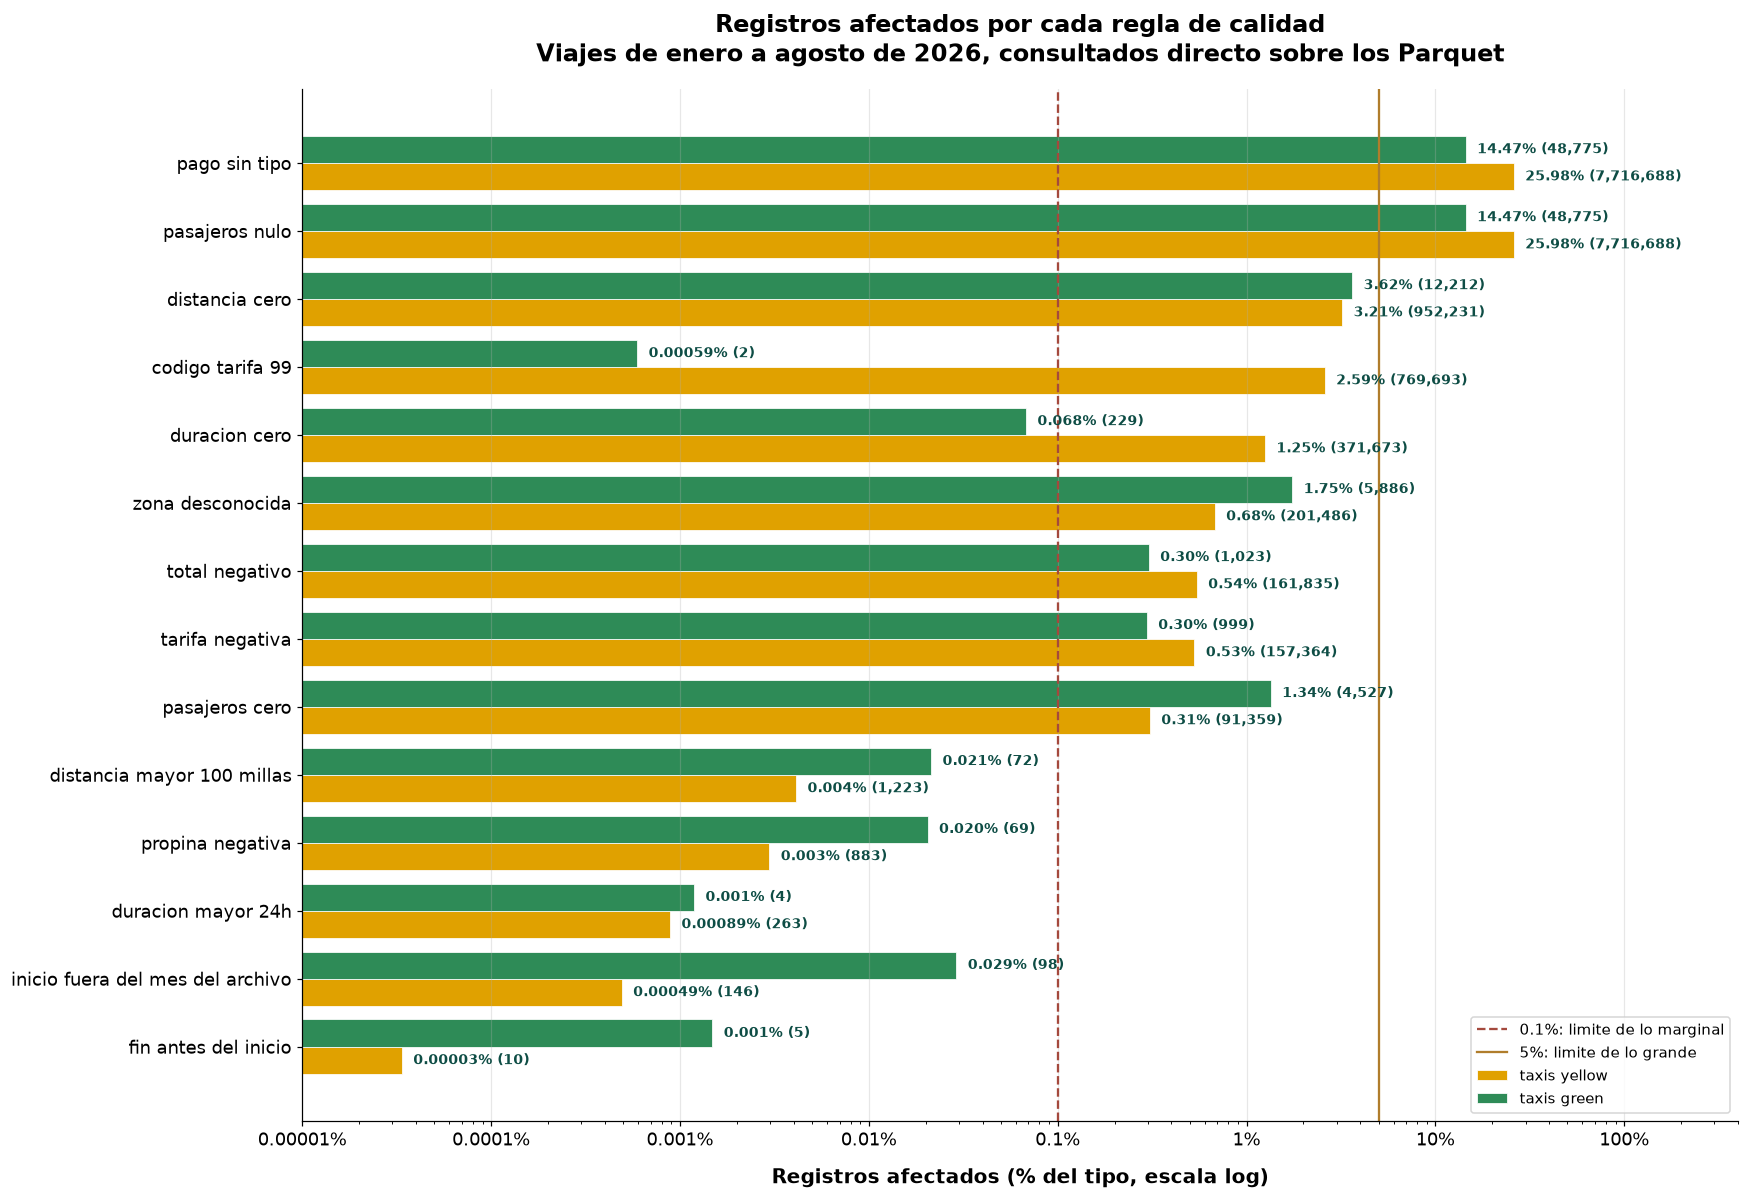

tipo,yellow,green,pct_yellow,pct_green,magnitud
inicio_fuera_del_mes_del_archivo,146,98,0.0005,0.0291,marginal (menos de 0.1%)
fin_antes_del_inicio,10,5,0.0000,0.0015,marginal (menos de 0.1%)
duracion_cero,371673,229,1.2513,0.0679,moderado (0.1% a 5%)
duracion_mayor_24h,263,4,0.0009,0.0012,marginal (menos de 0.1%)
distancia_cero,952231,12212,3.2058,3.6225,moderado (0.1% a 5%)
distancia_mayor_100_millas,1223,72,0.0041,0.0214,marginal (menos de 0.1%)
tarifa_negativa,157364,999,0.5298,0.2963,moderado (0.1% a 5%)
total_negativo,161835,1023,0.5448,0.3035,moderado (0.1% a 5%)
propina_negativa,883,69,0.0030,0.0205,marginal (menos de 0.1%)
pasajeros_nulo,7716688,48775,25.9792,14.4684,grande (5% o mas)


In [12]:
calidad = correr(con, "02_calidad.sql")
tabla_calidad = calidad_larga(calidad)
fig, ax = graficar_calidad(tabla_calidad)
plt.show()
tabla_calidad.round(4)

Las 14 reglas quedan en 2 problemas grandes, 7 moderados y 5 marginales:

- **Grandes.** Pasajeros nulos y pago sin tipo afectan exactamente a las mismas cantidades, 7,716,688 amarillos (25.98%) y 48,775 verdes (14.47%).
- **Moderados.** Distancia cero en 3.2% de los amarillos y 3.6% de los verdes; codigo de tarifa 99 en 2.59% de los amarillos pero solo 2 verdes; duracion cero en 1.25% de los amarillos contra 0.07% de los verdes; zona desconocida en 0.68% y 1.75%; tarifa negativa en 0.53% y 0.30%; cero pasajeros en 0.31% y 1.34%.
- **Marginales.** Viajes fuera del mes de su archivo (146 y 98), llegada antes de la salida (10 y 5), mas de 24 horas (263 y 4), mas de 100 millas (1,223 y 72) y propina negativa (883 y 69).

Lo mas util es donde los dos tipos difieren. El codigo 99 y la duracion cero son problemas casi exclusivos de los amarillos. Cuando un problema aparece en un solo servicio, la causa suele ser quien genera el dato y no el viaje, y eso es lo que revisa el paso 7.9.

### 7.8 Nulos segun el tipo de pago (3.6)

In [13]:
correr(con, "02_nulos_por_pago.sql")

-- 02_nulos_por_pago.sql
-- Objetivo: ver si los nulos de pasajeros, codigo de tarifa y recargos estan
-- repartidos al azar o concentrados en un tipo de pago (3.6).
-- Fuente: data/raw/*/*/*.parquet, directo.
select
    split_part(filename, '/', -3) as tipo,
    payment_type,
    count(*) as registros,
    count(*) - count(passenger_count) as sin_pasajeros,
    count(*) - count(RatecodeID) as sin_codigo_tarifa,
    count(*) - count(store_and_fwd_flag) as sin_store_and_fwd,
    count(*) - count(congestion_surcharge) as sin_recargo_congestion
from read_parquet('data/raw/*/*/*.parquet', union_by_name = true, filename = true)
group by all
order by tipo desc, payment_type nulls last;



,tipo,payment_type,registros,sin_pasajeros,sin_codigo_tarifa,sin_store_and_fwd,sin_recargo_congestion
0,yellow,0,7716688,7716688,7716688,7716688,7716688
1,yellow,1,18941008,0,0,0,0
2,yellow,2,2708031,0,0,0,0
3,yellow,3,98138,0,0,0,0
4,yellow,4,239488,0,0,0,0
5,yellow,5,2,0,0,0,0
6,green,1,219980,0,0,0,0
7,green,2,65921,0,0,0,0
8,green,3,1688,0,0,0,0
9,green,4,750,0,0,0,0


Los nulos no estan repartidos al azar. Los 7,716,688 amarillos sin pasajeros son exactamente los 7,716,688 con `payment_type` 0, y en esas mismas filas faltan tambien el codigo de tarifa, `store_and_fwd_flag` y el recargo de congestion. En los verdes pasa lo mismo con las 48,775 filas sin tipo de pago. Ningun otro tipo de pago tiene un solo nulo en esas cuatro columnas.

El diccionario de la TLC define el codigo 0 como "Flex Fare trip", viajes de tarifa flexible. No son registros danados sino otra clase de viaje, que el sistema reporta con menos campos. Son el 26% de los amarillos, asi que eliminarlos cambiaria cualquier conteo. La decision es conservarlos y dejarlos fuera solo de los analisis que necesitan pasajeros, codigo de tarifa o recargos.

### 7.9 Problemas por proveedor (3.6)

In [14]:
display(correr(con, "02_calidad_por_proveedor.sql"))
correr(con, "02_negativos_por_pago.sql")

-- 02_calidad_por_proveedor.sql
-- Objetivo: ver si los problemas de calidad estan repartidos entre los
-- proveedores de tecnologia (VendorID) o concentrados en alguno (3.6).
-- Fuente: data/raw/*/*/*.parquet, directo.
-- VendorID segun el diccionario de la TLC: 1 Creative Mobile Technologies,
-- 2 Curb Mobility, 6 Myle Technologies, 7 Helix.
select
    split_part(filename, '/', -3) as tipo,
    VendorID,
    count(*) as registros,
    count_if(coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)
             = coalesce(tpep_pickup_datetime, lpep_pickup_datetime)) as duracion_cero,
    count_if(trip_distance = 0) as distancia_cero,
    count_if(fare_amount < 0) as tarifa_negativa,
    count_if(RatecodeID = 99) as codigo_tarifa_99,
    count_if(payment_type is null or payment_type = 0) as pago_sin_tipo,
    count_if(passenger_count = 0) as pasajeros_cero
from read_parquet('data/raw/*/*/*.parquet', union_by_name = true, filename = true)
group by all
order by tipo desc, VendorID;



,tipo,VendorID,registros,duracion_cero,distancia_cero,tarifa_negativa,codigo_tarifa_99,pago_sin_tipo,pasajeros_cero
0,yellow,1,5467071,4297.0,90444.0,0.0,769133.0,895381.0,81915.0
1,yellow,2,23809774,256.0,855041.0,157364.0,560.0,6761917.0,9444.0
2,yellow,6,59390,0.0,0.0,0.0,NaN,59390.0,NaN
3,yellow,7,367120,367120.0,6746.0,0.0,0.0,0.0,0.0
4,green,1,28696,86.0,1694.0,0.0,2.0,528.0,4166.0
5,green,2,273571,143.0,10518.0,999.0,0.0,13400.0,361.0
6,green,6,34847,0.0,0.0,0.0,NaN,34847.0,NaN


-- 02_negativos_por_pago.sql
-- Objetivo: con que tipo de pago y proveedor vienen los viajes con tarifa
-- negativa, para saber si son errores de captura o ajustes (3.6).
-- Fuente: data/raw/*/*/*.parquet, directo.
-- payment_type segun el diccionario de la TLC: 0 Flex Fare, 1 tarjeta,
-- 2 efectivo, 3 sin cargo, 4 disputa, 5 desconocido, 6 viaje anulado.
select
    split_part(filename, '/', -3) as tipo,
    VendorID,
    payment_type,
    count(*) as registros,
    round(median(fare_amount), 2) as tarifa_mediana
from read_parquet('data/raw/*/*/*.parquet', union_by_name = true, filename = true)
where fare_amount < 0
group by all
order by tipo desc, registros desc;



,tipo,VendorID,payment_type,registros,tarifa_mediana
0,yellow,2,4,100849,-12.80
1,yellow,2,2,35068,-13.50
2,yellow,2,3,17726,-10.00
3,yellow,2,1,3500,-3.70
4,yellow,2,0,221,-3.96
5,green,2,3,564,-3.00
6,green,2,4,279,-5.10
7,green,2,1,137,-3.00
8,green,2,2,17,-12.10
9,green,2,<NA>,2,-4.33


Tres de los problemas tienen un responsable claro:

- **Proveedor 7 (Helix):** sus 367,120 viajes amarillos, el 100%, llegan en el mismo segundo en que salen, en los 8 meses. Son casi toda la duracion cero de los amarillos (367,120 de 371,673). Este proveedor no registra la hora de llegada: sus viajes sirven para contar, pero no para medir duracion ni velocidad.
- **Proveedor 1 (Creative Mobile Technologies):** genera 769,133 de los 769,693 codigos de tarifa 99, el 14.1% de sus propios viajes.
- **Proveedor 2 (Curb Mobility):** es el unico con tarifas negativas, 157,364 amarillas y 999 verdes. La segunda tabla dice que son: en amarillos, 100,849 vienen con pago en disputa (64%), 35,068 en efectivo y 17,726 sin cargo, con medianas de -12.80, -13.50 y -10.00 dolares. Son el valor de una tarifa normal con signo contrario, asi que se comportan como reversiones de un cobro y no como errores de captura.

El proveedor 6 (Myle) nunca reporta tipo de pago ni pasajeros, en amarillos ni en verdes, y la distancia cero si esta repartida entre proveedores. Para el analisis, cada problema se filtra solo en las preguntas a las que afecta, en lugar de borrar proveedores completos.

### 7.10 Viajes fuera del mes de su archivo (3.6)

In [15]:
correr(con, "02_fuera_de_mes.sql")

-- 02_fuera_de_mes.sql
-- Objetivo: de los viajes cuya fecha de inicio no cae en el mes de su archivo,
-- a que mes corresponden y en que archivos estan (3.6).
-- Fuente: data/raw/*/*/*.parquet, directo.
with v as (
    select
        split_part(filename, '/', -3) as tipo,
        regexp_extract(filename, '(\d{4}-\d{2})\.parquet$', 1) as mes_archivo,
        strftime(coalesce(tpep_pickup_datetime, lpep_pickup_datetime), '%Y-%m') as mes_inicio
    from read_parquet('data/raw/*/*/*.parquet', union_by_name = true, filename = true)
)
select
    tipo,
    mes_inicio,
    count(*) as registros,
    string_agg(distinct mes_archivo, ', ' order by mes_archivo) as archivos
from v
where mes_inicio <> mes_archivo
group by tipo, mes_inicio
order by tipo desc, mes_inicio;



,tipo,mes_inicio,registros,archivos
0,yellow,2001-01,1,2026-04
1,yellow,2008-12,4,"2026-03, 2026-05, 2026-06, 2026-07"
2,yellow,2009-01,6,"2026-03, 2026-04, 2026-05, 2026-08"
3,yellow,2025-12,6,2026-01
4,yellow,2026-01,12,2026-02
5,yellow,2026-02,16,"2026-01, 2026-03"
6,yellow,2026-03,11,"2026-02, 2026-04"
7,yellow,2026-04,28,"2026-03, 2026-05, 2026-06"
8,yellow,2026-05,2,"2026-04, 2026-06"
9,yellow,2026-06,8,"2026-05, 2026-07"


Solo 244 viajes (146 amarillos y 98 verdes) empiezan fuera del mes de su archivo, el 0.0008% del total, y son de dos clases. La mayoria, 223, cae en un mes vecino: por ejemplo 38 viajes que empiezan en agosto estan en el archivo de julio. Los otros 21 tienen fechas imposibles, del 31 de diciembre de 2008 o el 1 de enero de 2009 (mas uno del 2001), repetidas en archivos de meses distintos. Esa fecha fija apunta a un reloj sin configurar en el equipo del taxi, aunque los datos no permiten confirmarlo. Para el analisis temporal se usa el mes del viaje solo cuando coincide con el de su archivo; los 244 quedan fuera y ningun total mensual cambia de forma visible.

### 7.11 Duplicados exactos (3.6)

In [16]:
correr(con, "02_duplicados.sql")

-- 02_duplicados.sql
-- Objetivo: filas repetidas exactamente igual en todas sus columnas (3.6).
-- Fuente: data/raw/<tipo>/*/*.parquet, directo, un tipo a la vez porque sus
-- columnas no son las mismas. group by all agrupa por todas las columnas de
-- select *, asi que cada grupo con mas de una fila es un duplicado exacto.
select
    'yellow' as tipo,
    count(*) as grupos_repetidos,
    coalesce(sum(n), 0) as filas_en_grupos,
    coalesce(sum(n - 1), 0) as filas_sobrantes
from (
    select *, count(*) as n
    from read_parquet('data/raw/yellow/*/*.parquet', union_by_name = true)
    group by all
    having count(*) > 1
)
union all
select
    'green',
    count(*),
    coalesce(sum(n), 0),
    coalesce(sum(n - 1), 0)
from (
    select *, count(*) as n
    from read_parquet('data/raw/green/*/*.parquet', union_by_name = true)
    group by all
    having count(*) > 1
);



,tipo,grupos_repetidos,filas_en_grupos,filas_sobrantes
0,yellow,7,14.0,7.0
1,green,0,0.0,0.0


Hay 7 pares de filas amarillas identicas en las 21 columnas, es decir 7 filas sobrantes entre 29.7 millones; en verdes no hay ninguno. Sin un identificador de viaje no se puede saber si son dos viajes que coinciden en todo (mismo segundo de salida y de llegada, mismas zonas, mismo monto) o un mismo registro enviado dos veces; lo segundo es mucho mas probable. Con 7 filas la decision no cambia ningun resultado, asi que se dejan como estan. Esta consulta es de las mas lentas del cuaderno porque, a diferencia de casi todas, tiene que leer las 21 columnas completas y agrupar por todas a la vez.

### 7.12 Que cuesta leer directo (3.9)

UNGROUPED_AGGREGATE
Aggregates: max(#0)
PROJECTION
fare_amount
~5,940,671 rows
READ_PARQUET
Function:
READ_PARQUET
Projections:
fare_amount
Filters:
tpep_pickup_datetime>=
'2026-08-01 00:00:00':
:TIMESTAMP
~5,940,671 rows


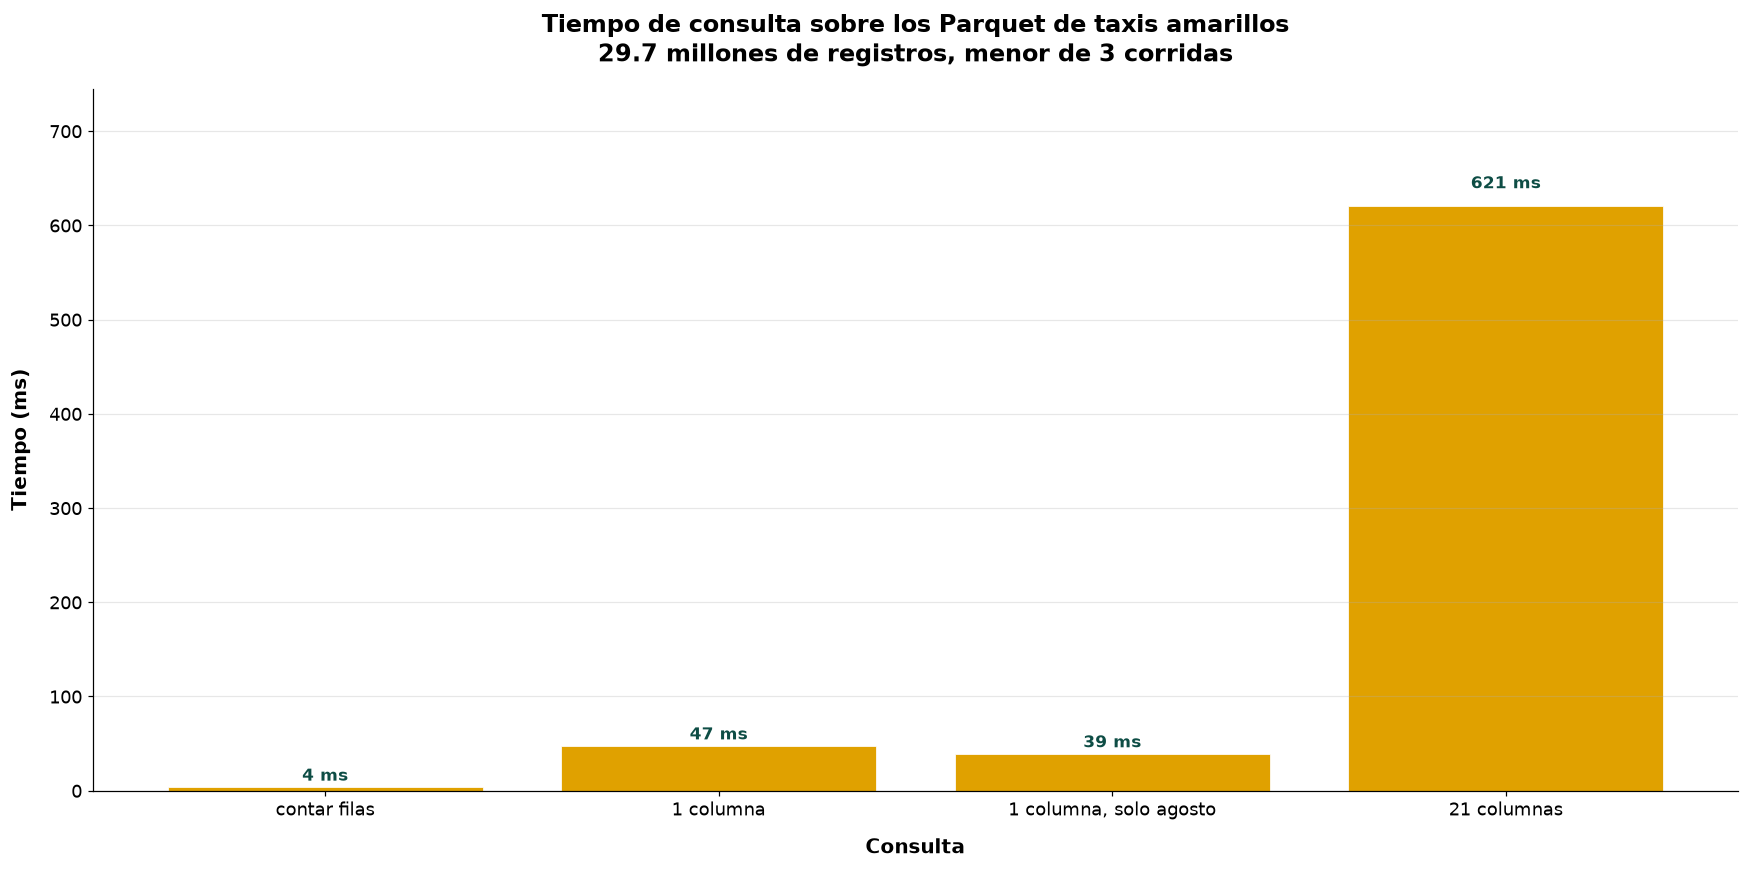

,consulta,archivo,segundos,veces_contar
0,contar filas,02_costo_conteo.sql,0.004290,1.000000
1,1 columna,02_costo_una_columna.sql,0.047238,11.011142
2,"1 columna, solo agosto",02_costo_filtro.sql,0.039015,9.094212
3,21 columnas,02_costo_todas.sql,0.620724,144.689575


In [17]:
pruebas = {
    "contar filas": "02_costo_conteo.sql",
    "1 columna": "02_costo_una_columna.sql",
    "1 columna, solo agosto": "02_costo_filtro.sql",
    "21 columnas": "02_costo_todas.sql",
}
costos = pd.DataFrame([{"consulta": k, "archivo": v, "segundos": medir(con, v)} for k, v in pruebas.items()])
print(plan_legible(plan(con, "02_costo_filtro.sql")))
fig, ax = graficar_costos(costos)
plt.show()
costos.assign(veces_contar=costos["segundos"] / costos["segundos"].min())

Las cuatro consultas recorren los mismos 29.7 millones de registros y el tiempo depende de cuanto del archivo necesitan leer de verdad:

- **Contar filas** tarda unos 4 ms: DuckDB suma el numero de filas que cada pie de archivo ya trae y no toca los datos.
- **El maximo de una columna** tarda entre 40 y 50 ms: solo se descomprime `fare_amount`, una de 21 columnas.
- **La misma columna filtrada a agosto** tarda un poco menos, y el plan muestra por que: `READ_PARQUET` recibe la unica columna necesaria (`Projections: fare_amount`) y el filtro (`Filters: tpep_pickup_datetime >= 2026-08-01`). DuckDB no lee todo para filtrar despues: filtra mientras lee, y puede saltarse grupos de filas cuyo rango de fechas, guardado en los metadatos, no cumple la condicion.
- **El mismo maximo sobre las 21 columnas** tarda alrededor de 0.6 s, mas de diez veces lo que cuesta una columna.

Sobre Parquet, el costo de una consulta depende de las columnas que toca, no de cuantas tiene el archivo. Por eso `select *` es lo mas caro que se le puede pedir a un Parquet, y las consultas del exploratorio piden solo las columnas que usan.

### 7.13 Bitacora de consultas (3.8)

In [18]:
bitacora = pd.DataFrame(BITACORA)
print(f"Consultas ejecutadas: {len(bitacora)} | tiempo total: {bitacora['segundos'].sum():.1f} s")
bitacora

Consultas ejecutadas: 18 | tiempo total: 21.8 s


,consulta,filas_resultado,segundos
0,02_archivos.sql,2,0.016
1,02_registros.sql,2,0.370
2,02_esquema.sql,43,0.049
3,02_tipos_duckdb.sql,25,0.006
4,02_muestra_yellow.sql,15,1.599
5,02_muestra_green.sql,13,0.028
6,02_resumen_yellow.sql,21,9.952
7,02_resumen_green.sql,22,0.131
8,02_calidad.sql,2,1.243
9,02_nulos_por_pago.sql,11,0.463


El cuaderno corrio 18 consultas en unos 20 segundos. Cerca de la mitad de ese tiempo es una sola, el perfil `SUMMARIZE` de los amarillos (unos 10 s), que calcula minimo, maximo, cuartiles y distintos de las 21 columnas. Le sigue la de duplicados (unos 5 s), que tambien necesita todas las columnas. Las demas tardan menos de 2 segundos cada una, varias menos de 50 ms. La documentacion completa de cada consulta (SQL, objetivo, archivos fuente, resultado y decision) esta en `docs/consultas.md`.

## 8. Conclusiones

**Respuesta.** Los 16 archivos de 2026 tienen 30,040,469 viajes: 29,703,355 amarillos (98.9%) y 337,114 verdes. Los amarillos traen 21 columnas y los verdes 22, con 18 nombres en comun, las fechas con prefijo distinto y una columna sin documentar (`request_source`) que aparece en junio. Ninguna columna cambia de tipo entre archivos. Los problemas de calidad existen pero estan localizados: casi todos se explican por un tipo de pago o por un proveedor, no por ruido repartido al azar.

**Decisiones para el analisis exploratorio (3.8).**

| Problema | Tamanio | Decision |
|---|---|---|
| `request_source` aparece en junio | 3 de 8 archivos por tipo | Leer siempre con `union_by_name = true`. No se analiza porque no esta documentada |
| `ehail_fee` siempre nula | 100% de los verdes | Se ignora |
| Viajes Flex Fare (`payment_type` 0 o nulo) sin pasajeros, codigo de tarifa ni recargos | 25.98% amarillos, 14.47% verdes | Se conservan; quedan fuera solo de analisis de pasajeros, codigo de tarifa o recargos |
| Proveedor 7 sin hora de llegada | 367,120 viajes amarillos | Fuera de duracion y velocidad |
| Codigo de tarifa 99 | 769,693, casi todos del proveedor 1 | Se trata como desconocido |
| Distancia cero o mayor a 100 millas | 3.2% amarillos, 3.6% verdes | Fuera de distancia y velocidad |
| Duracion negativa, cero o mayor a 24 horas | 1.25% amarillos, 0.07% verdes | Fuera de duracion y velocidad |
| Montos negativos (reversiones del proveedor 2) | 0.54% amarillos, 0.30% verdes | Fuera de todo el analisis: son ajustes, no viajes |
| Inicio fuera del mes de su archivo | 244 viajes | Fuera de todo el analisis |
| Zonas 264 y 265 (desconocida, fuera de NYC) | 0.68% amarillos, 1.75% verdes | Fuera solo de analisis por zona o barrio |
| Duplicados exactos | 7 filas | Se dejan |
| Propinas | El diccionario dice que solo se registran las de tarjeta | Propina solo en viajes pagados con tarjeta |

**Que significa consultar directo un Parquet (3.9).** Es ejecutar SQL sobre el archivo tal como esta en disco, sin importarlo antes a una base de datos ni cargarlo completo en memoria. Funciona bien con mucho volumen por como esta hecho Parquet. Guarda cada columna por separado y comprimida, y al final de cada archivo trae metadatos: cuantas filas tiene cada grupo y el minimo y el maximo de cada columna en ese grupo. Con eso DuckDB puede contar filas sin leer datos (unos 4 ms para 29.7 millones), leer solo las columnas que la consulta usa (entre 40 y 50 ms una columna contra 0.6 s las 21) y filtrar durante la lectura. No hay paso de carga ni copia: los 496 MiB comprimidos se consultan en su lugar, cuando 30 millones de filas de 21 columnas de 8 bytes ocuparian del orden de 5 GB descomprimidas en memoria. Y como los archivos se leen con un patron (`data/raw/yellow/*/*.parquet`), un mes nuevo entra en la siguiente consulta sin cambiar nada. El precio es que cada consulta vuelve a leer y descomprimir lo que necesita; si las mismas consultas pesadas se repiten muchas veces, una tabla materializada puede salir mas barata, que es justo lo que compara el ejercicio 6.

**Limitaciones.** Los umbrales de las reglas (100 millas, 24 horas) son decisiones del equipo, no del diccionario. Las reglas se cuentan por separado y un mismo viaje puede caer en varias, asi que los porcentajes no se suman. Que los montos negativos sean reversiones se infiere de su tipo de pago y su valor tipico; la TLC no lo documenta.

**Siguiente paso.** El cuaderno 03 aplica estas decisiones en una vista de viajes validos y responde las preguntas del analisis exploratorio (ejercicio 4).